In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load the dataset
df = pd.read_csv('/content/Pharma_Industry.csv')

In [21]:
df.shape

(500, 6)

In [22]:
# --- Fundamental Data Exploration ---
print("--- Dataset Info ---")
print(df.info())
print("\n--- Summary Statistics ---")
print(df.describe())

--- Dataset Info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 6 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Drug Dosage (mg)                500 non-null    float64
 1   Systolic Blood Pressure (mmHg)  500 non-null    float64
 2   Heart Rate (BPM)                500 non-null    float64
 3   Liver Toxicity Index (U/L)      500 non-null    float64
 4   Blood Glucose Level (mg/dL)     500 non-null    float64
 5   Drug Response                   500 non-null    int64  
dtypes: float64(5), int64(1)
memory usage: 23.6 KB
None

--- Summary Statistics ---
       Drug Dosage (mg)  Systolic Blood Pressure (mmHg)  Heart Rate (BPM)  \
count        500.000000                      500.000000        500.000000   
mean          -0.037761                        0.214957          0.062871   
std            0.979891                        1.247567          0.97197

In [23]:
# Check target balance (0 = No Response, 1 = Positive Response)
print("\n--- Drug Response Distribution ---")
print(df['Drug Response'].value_counts())

# Identify features for visualization
features = [
    'Drug Dosage (mg)', 'Systolic Blood Pressure (mmHg)',
    'Heart Rate (BPM)', 'Liver Toxicity Index (U/L)',
    'Blood Glucose Level (mg/dL)'
]


--- Drug Response Distribution ---
Drug Response
1    260
0    240
Name: count, dtype: int64


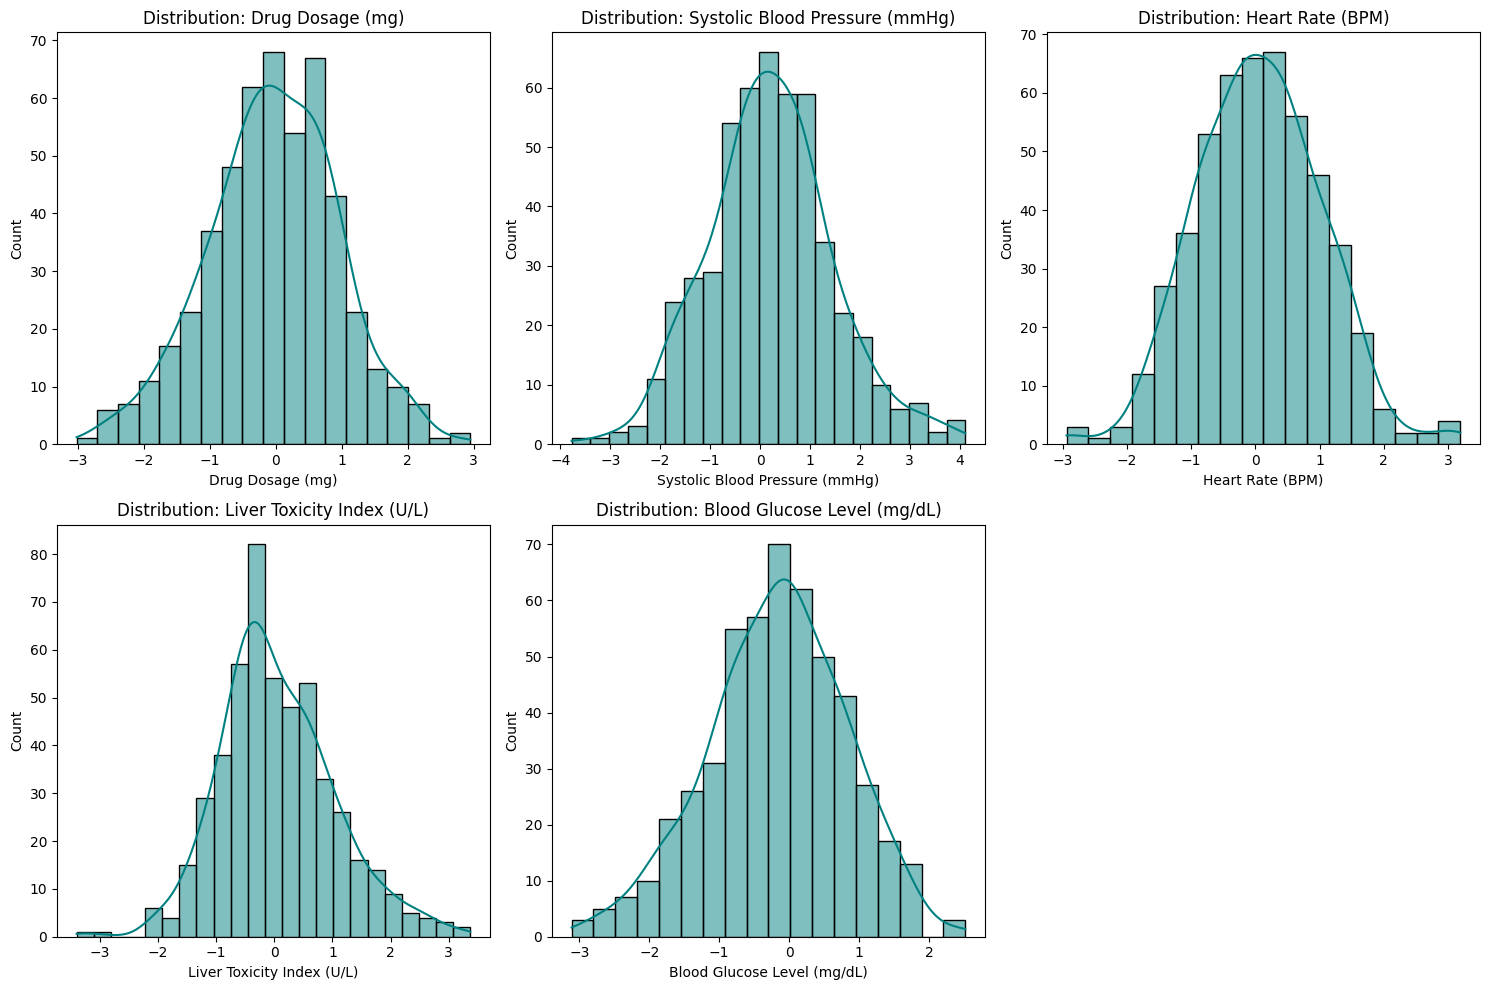

In [24]:
# --- Feature Distributions (Histograms) ---
# Helps understand if the biomarkers follow a normal distribution
plt.figure(figsize=(15, 10))
for i, col in enumerate(features, 1):
    plt.subplot(2, 3, i)
    sns.histplot(df[col], kde=True, color='teal')
    plt.title(f'Distribution: {col}')
plt.tight_layout()
plt.savefig('feature_distributions.png')

/tmp/ipython-input-1546176228.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Drug Response', y=col, data=df, palette='viridis')
/tmp/ipython-input-1546176228.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Drug Response', y=col, data=df, palette='viridis')
/tmp/ipython-input-1546176228.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Drug Response', y=col, data=df, palette='viridis')
/tmp/ipython-input-1546176228.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0

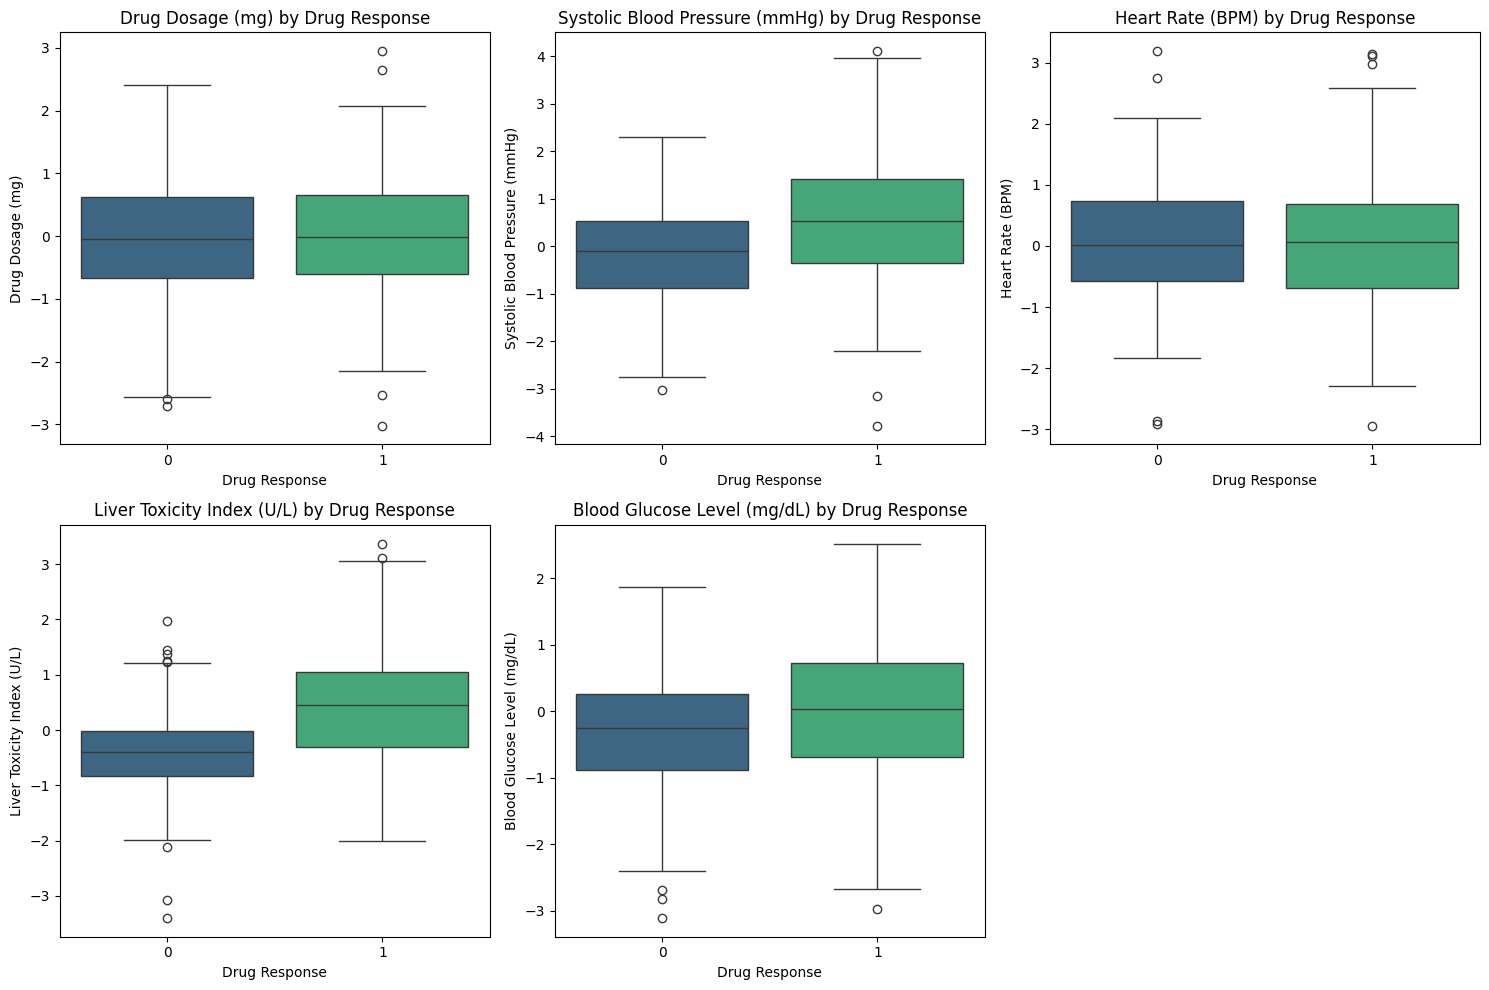

In [25]:
# --- Feature vs Drug Response (Box Plots) ---
# Helps identify which biomarkers differ most between responders and non-responders
plt.figure(figsize=(15, 10))
for i, col in enumerate(features, 1):
    plt.subplot(2, 3, i)
    sns.boxplot(x='Drug Response', y=col, data=df, palette='viridis')
    plt.title(f'{col} by Drug Response')
plt.tight_layout()
plt.savefig('box_plots_by_response.png')


EDA Visualizations have been saved as PNG files.


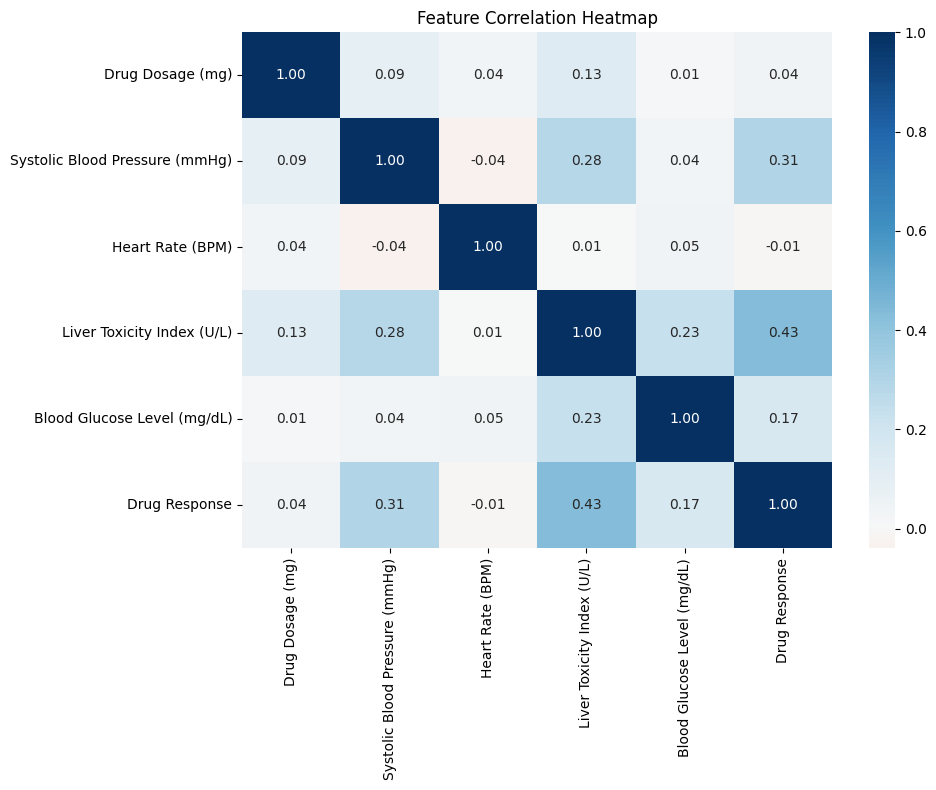

In [26]:
# --- Feature Correlation (Heatmap) ---
# Investigate relationships between different biological markers
plt.figure(figsize=(10, 8))
corr = df.corr()
sns.heatmap(corr, annot=True, cmap='RdBu', center=0, fmt=".2f")
plt.title("Feature Correlation Heatmap")
plt.tight_layout()
plt.savefig('correlation_heatmap.png')

print("\nEDA Visualizations have been saved as PNG files.")

##Key Insights from the Analysis


* Target Balance: The dataset is well-balanced with 260 Positive Responses (1) and 240 No Responses (0).
* Data Scaling: The biomarker features (Blood Pressure, Heart Rate, etc.) appear to be pre-scaled or standardized, as most means are near $0$ and values generally range between $-3$ and $3$.
* Feature Distributions: The histograms allow us to confirm if there are any significant outliers or skewness in the biological data before training the classification model.
* Correlations: The heatmap will reveal if certain biomarkers (like Heart Rate and Systolic Blood Pressure) move together, which can help in feature selection.

In [27]:
from sklearn.model_selection import train_test_split

# Check for categorical variables
categorical_cols = df.select_dtypes(include=['object', 'category']).columns.tolist()
print(f"Categorical columns found: {categorical_cols}")

# Define Features (X) and Target (y)
# X contains the biomarkers: Dosage, BP, Heart Rate, Liver Toxicity, Glucose
# y contains the label: Drug Response (0 or 1)
X = df.drop(columns=['Drug Response'])
y = df['Drug Response']

# Split the dataset into training and testing sets
# We use an 80/20 split (test_size=0.2).
# stratify=y is used to maintain the ratio of 'No Response' to 'Positive Response' in both sets.
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=54,
    stratify=y
)

print(f"Preprocessing Complete:")
print(f"- Training set: {X_train.shape[0]} samples")
print(f"- Testing set: {X_test.shape[0]} samples")

Categorical columns found: []
Preprocessing Complete:
- Training set: 400 samples
- Testing set: 100 samples


/tmp/ipython-input-829755383.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Drug Response', data=df, palette='magma')


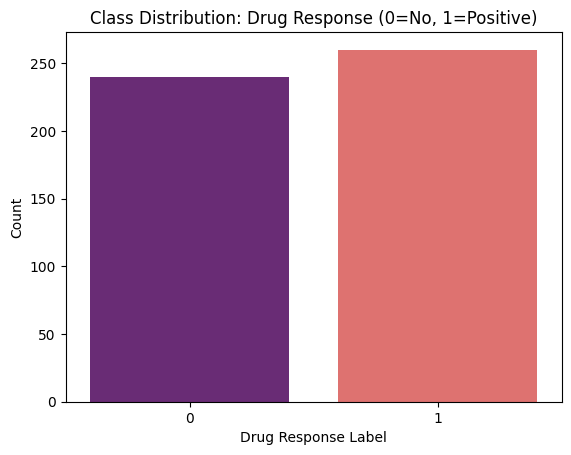

In [28]:
# Class Distribution Visualization ---
sns.countplot(x='Drug Response', data=df, palette='magma')
plt.title('Class Distribution: Drug Response (0=No, 1=Positive)')
plt.xlabel('Drug Response Label')
plt.ylabel('Count')
plt.show()

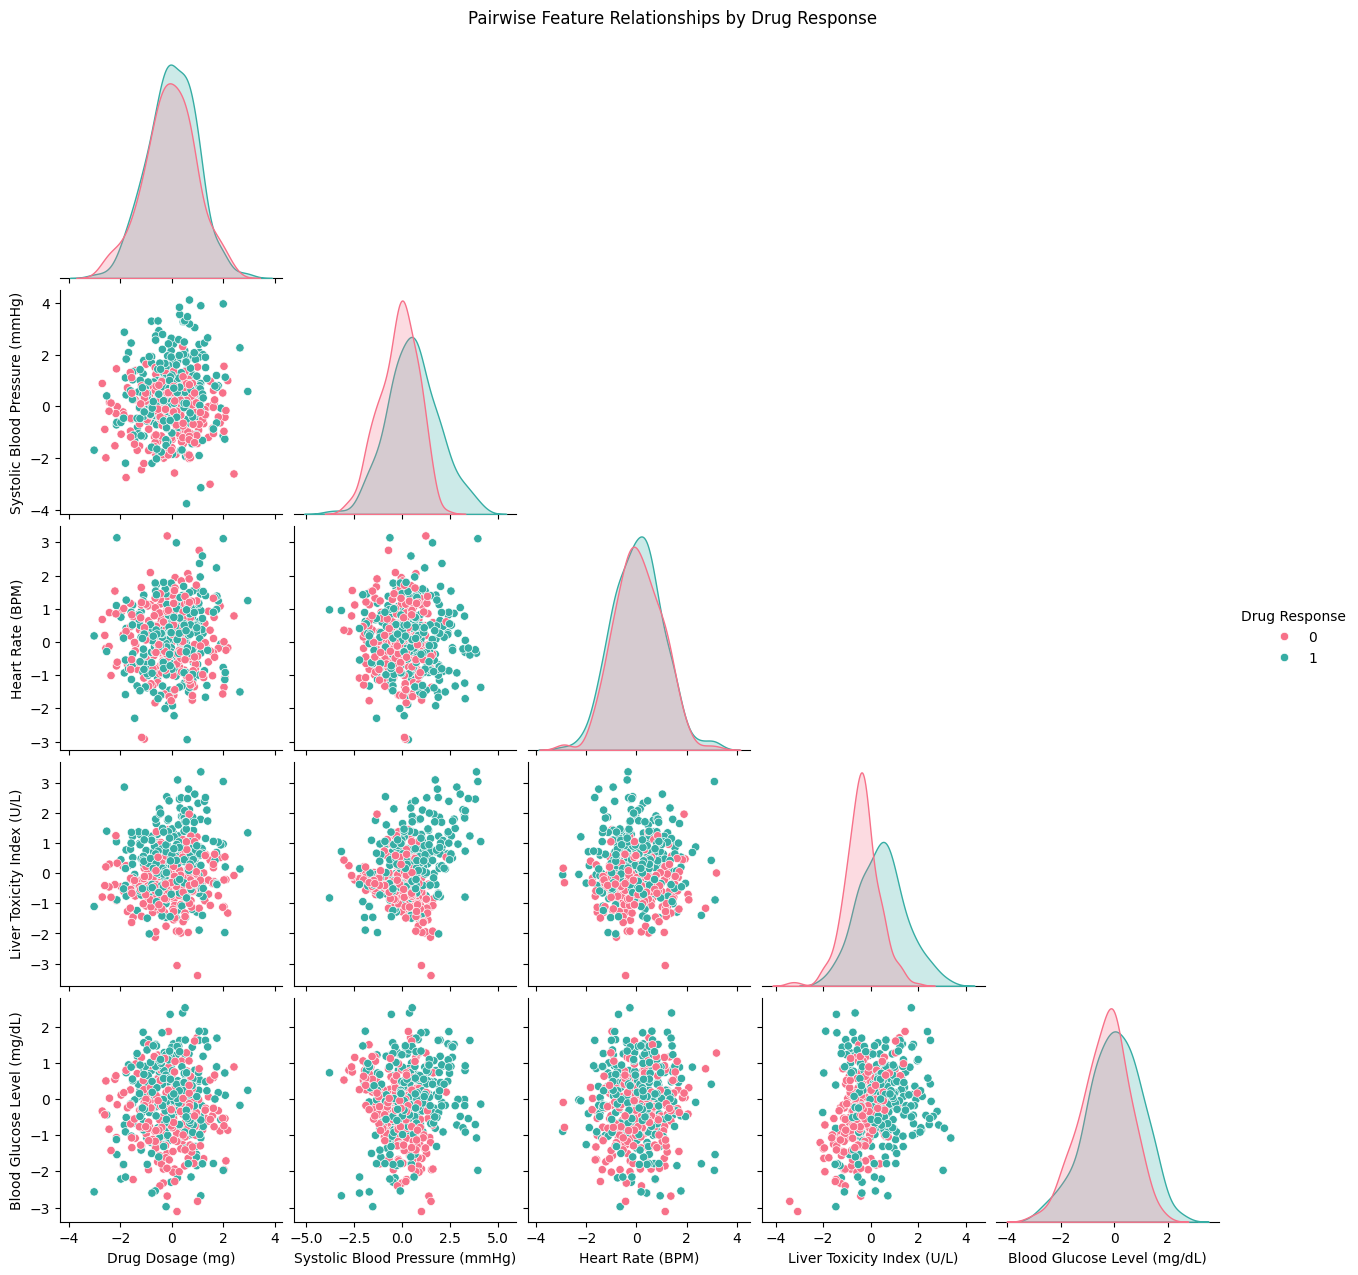

In [29]:
# Pair Plot ---
sns.pairplot(df, hue='Drug Response', palette='husl', corner=True, diag_kind='kde')
plt.suptitle('Pairwise Feature Relationships by Drug Response', y=1.02)
plt.show()

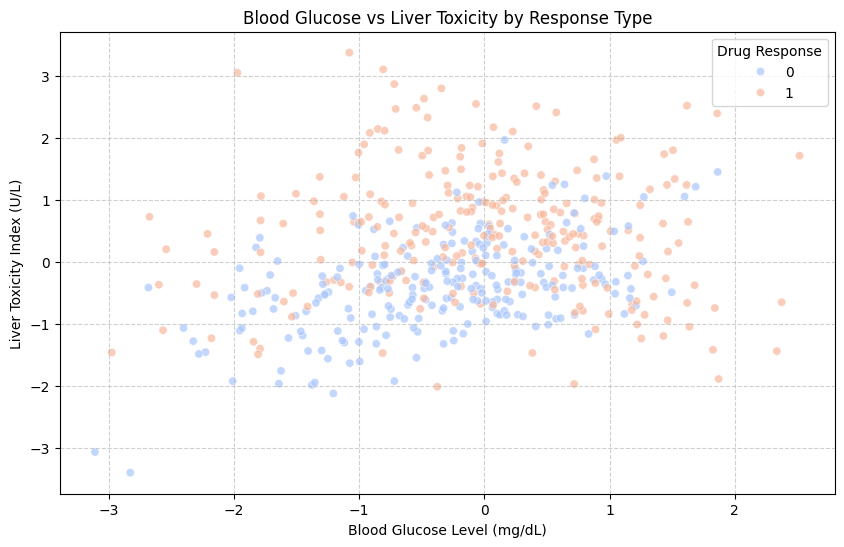

In [30]:
#  Targeted Scatter Plot ---
plt.figure(figsize=(10, 6))
sns.scatterplot(
    x='Blood Glucose Level (mg/dL)',
    y='Liver Toxicity Index (U/L)',
    hue='Drug Response',
    data=df,
    alpha=0.7,
    palette='coolwarm'
)
plt.title('Blood Glucose vs Liver Toxicity by Response Type')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

--- SVM Model Evaluation ---
Accuracy Score: 0.7400

Classification Report:
                       precision    recall  f1-score   support

      No Response (0)       0.71      0.77      0.74        48
Positive Response (1)       0.77      0.71      0.74        52

             accuracy                           0.74       100
            macro avg       0.74      0.74      0.74       100
         weighted avg       0.74      0.74      0.74       100



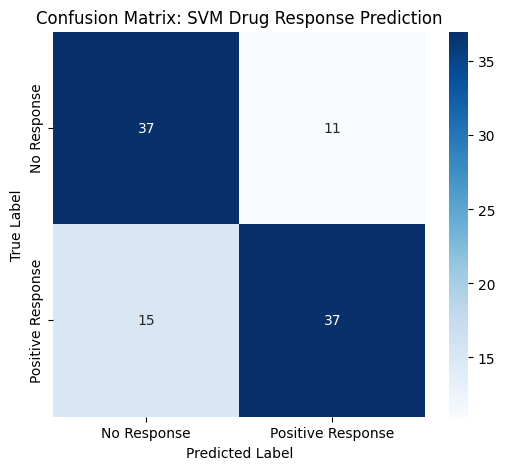

In [31]:
from sklearn.svm import SVC
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
# Initialize the SVM Classifier
svm_model = SVC(kernel='rbf', random_state=82)

# Train the model
svm_model.fit(X_train, y_train)

# Make predictions on the testing data
y_pred = svm_model.predict(X_test)

# Evaluate Performance
print("--- SVM Model Evaluation ---")
print(f"Accuracy Score: {accuracy_score(y_test, y_pred):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=['No Response (0)', 'Positive Response (1)']))

# Visualize the Confusion Matrix
plt.figure(figsize=(6, 5))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Response', 'Positive Response'],
            yticklabels=['No Response', 'Positive Response'])
plt.title('Confusion Matrix: SVM Drug Response Prediction')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

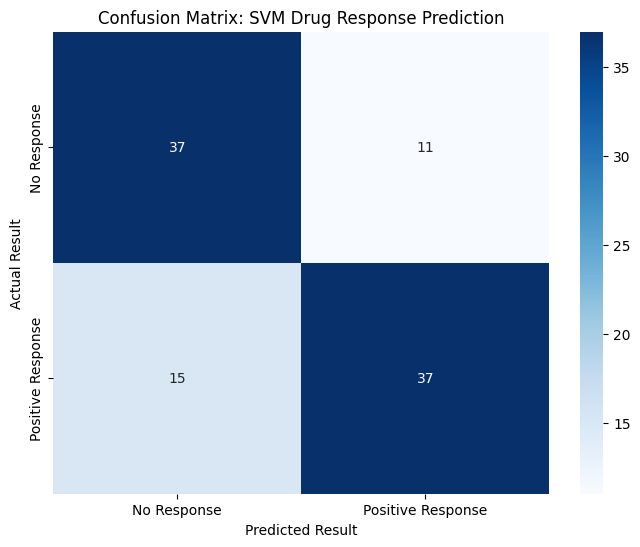

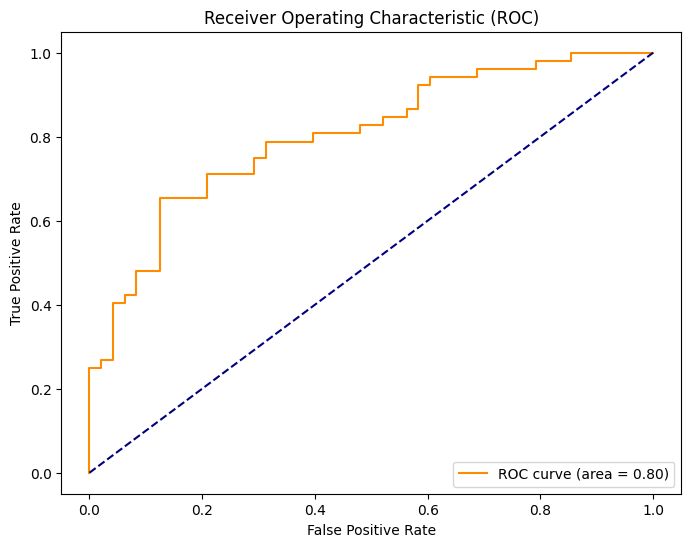

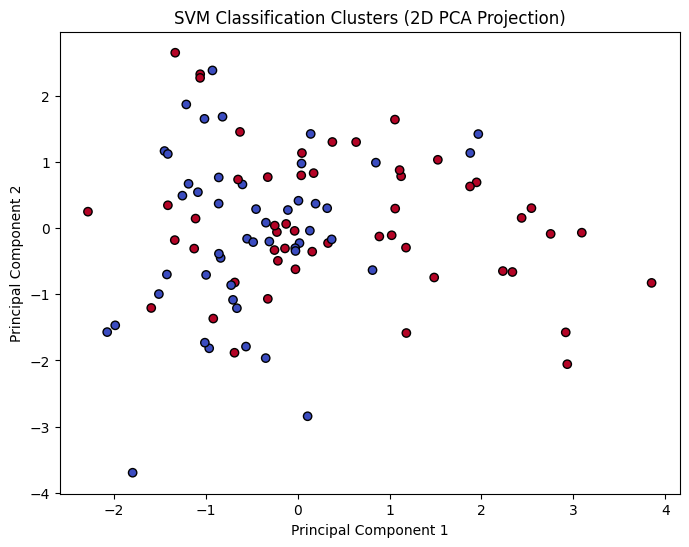

In [35]:
from sklearn.metrics import roc_curve, auc

# Confusion Matrix Visualization
plt.figure(figsize=(8, 6))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Response', 'Positive Response'],
            yticklabels=['No Response', 'Positive Response'])
plt.title('Confusion Matrix: SVM Drug Response Prediction')
plt.ylabel('Actual Result')
plt.xlabel('Predicted Result')
plt.show()

# Calculate scores for ROC Curve
y_score = svm_model.decision_function(X_test)

# ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_score)
roc_auc = auc(fpr, tpr)
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', label=f'ROC curve (area = {roc_auc:0.2f})')
plt.plot([0, 1], [0, 1], color='navy', linestyle='--')
plt.title('Receiver Operating Characteristic (ROC)')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend(loc="lower right")
plt.show()

# PCA-based Decision Boundary
from sklearn.decomposition import PCA
pca = PCA(n_components=2)
# Using X_test as X_test_scaled was not defined
X_test_pca = pca.fit_transform(X_test)
plt.figure(figsize=(8, 6))
plt.scatter(X_test_pca[:, 0], X_test_pca[:, 1], c=y_test, cmap='coolwarm', edgecolors='k')
plt.title('SVM Classification Clusters (2D PCA Projection)')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.show()

In [33]:
from sklearn.model_selection import GridSearchCV
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler

# Scale the data (SVM is highly sensitive to the scale of features)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Define the Parameter Grid
# C: Regularization parameter (controls the trade-off between smooth boundary and classifying training points correctly)
# Gamma: Kernel coefficient (defines how far the influence of a single training point reaches)
# Kernel: Type of hyperplane used to separate the data
param_grid = {
    'C': [0.1, 1, 10, 100],
    'gamma': ['scale', 'auto', 0.1, 0.01, 0.001],
    'kernel': ['rbf', 'poly', 'sigmoid']
}

# Implement Grid Search with 5-fold Cross-Validation
grid = GridSearchCV(SVC(random_state=42), param_grid, refit=True, verbose=1, cv=5)
grid.fit(X_train_scaled, y_train)

# Results
print(f"Best Parameters: {grid.best_params_}")
best_svm = grid.best_estimator_
y_optimized_pred = best_svm.predict(X_test_scaled)

Fitting 5 folds for each of 60 candidates, totalling 300 fits
Best Parameters: {'C': 1, 'gamma': 0.1, 'kernel': 'rbf'}


--- SVM Kernel Comparison ---
Kernel: Linear
Accuracy: 0.6500
              precision    recall  f1-score   support

           0       0.61      0.75      0.67        48
           1       0.71      0.56      0.62        52

    accuracy                           0.65       100
   macro avg       0.66      0.65      0.65       100
weighted avg       0.66      0.65      0.65       100

------------------------------
Kernel: Poly
Accuracy: 0.6400
              precision    recall  f1-score   support

           0       0.59      0.79      0.68        48
           1       0.72      0.50      0.59        52

    accuracy                           0.64       100
   macro avg       0.66      0.65      0.63       100
weighted avg       0.66      0.64      0.63       100

------------------------------
Kernel: Rbf
Accuracy: 0.7400
              precision    recall  f1-score   support

           0       0.71      0.77      0.74        48
           1       0.77      0.71      0.74        52


/usr/local/lib/python3.12/dist-packages/sklearn/svm/_base.py:305: ConvergenceWarning: Solver terminated early (max_iter=2000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(
/tmp/ipython-input-2290637970.py:36: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=list(results.keys()), y=list(results.values()), palette='viridis')


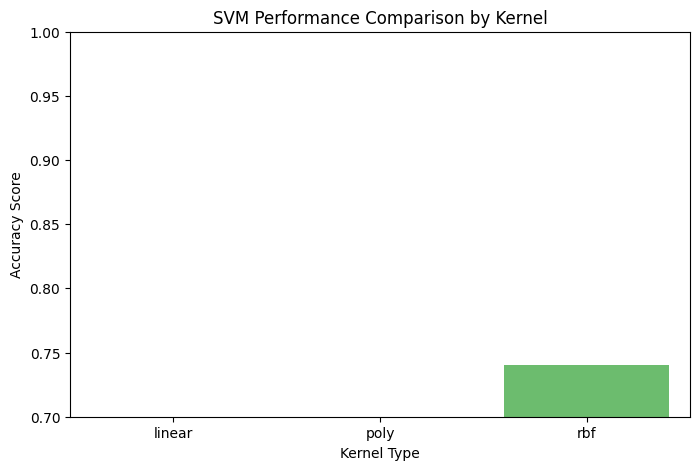

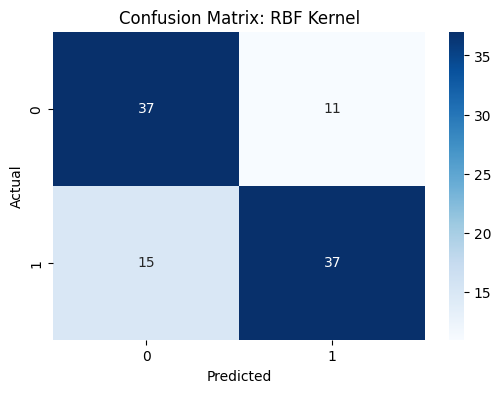

In [34]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix

# Setup and Splitting
# Assuming X and y are already preprocessed (encoded and scaled)
# X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

kernels = ['linear', 'poly', 'rbf']
results = {}

print("--- SVM Kernel Comparison ---")

# Iterating through various kernels
for kernel in kernels:
    # We use a small cache_size and limited iterations if the dataset is large
    # to avoid long wait times.
    model = SVC(kernel=kernel, max_iter=2000)
    model.fit(X_train, y_train)

    predictions = model.predict(X_test)
    acc = accuracy_score(y_test, predictions)
    results[kernel] = acc

    print(f"Kernel: {kernel.capitalize()}")
    print(f"Accuracy: {acc:.4f}")
    print(classification_report(y_test, predictions))
    print("-" * 30)

# Visualization of Accuracy
plt.figure(figsize=(8, 5))
sns.barplot(x=list(results.keys()), y=list(results.values()), palette='viridis')
plt.title('SVM Performance Comparison by Kernel')
plt.ylabel('Accuracy Score')
plt.xlabel('Kernel Type')
plt.ylim(0.7, 1.0) # Zooming in to see differences
plt.show()

# Confusion Matrix for the best performing kernel (usually RBF)
best_model = SVC(kernel='rbf', max_iter=2000).fit(X_train, y_train)
cm = confusion_matrix(y_test, best_model.predict(X_test))

plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix: RBF Kernel')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

##SVM Strengths and Weaknesses (Adult Dataset)
Based on your preprocessing of features like workclass, education_num, and hours_per_week, here is an analysis of how SVM stacks up:

##**Strengths**

Effective in High Dimensions: After one-hot encoding categorical variables (like native_country or occupation), your feature count increases significantly. SVM handles this "curse of dimensionality" better than many other algorithms.

Robustness to Outliers: SVM focuses on the "support vectors" (points near the boundary). In the Adult dataset, outliers in capital_gain won't sway the entire model as much as they might in Linear Regression.

Memory Efficiency: It only uses a subset of training points (support vectors) in the decision function.

##**Weaknesses**

Scaling Sensitivity: As you noted in your preprocessing task, SVM is not scale-invariant. If you don't scale fnlwgt and age, the larger numbers will dominate the distance calculations, leading to poor results.

Long Training Times: The Adult dataset has over 32,000 rows. SVM (especially with non-linear kernels) can be very slow to train compared to Random Forests or Logistic Regression.

Probability Interpretation: SVM doesn't naturally provide probability scores (like "there is a 70% chance this person earns >50k"); it just gives a classification.

##Practical Implications in the Real
###**SVM isn't just an academic exercise; it has specific niches in industry:**
* Bioinformatics: Often used for protein fold and cancer classification where the number of features (genes) is much larger than the number of samples.
* Text Categorization: Excellent for spam detection or sentiment analysis because text data is sparse and high-dimensional.
* Image Recognition: Used for handwriting recognition and face detection (though deep learning has largely taken over the latter).
* Financial Fraud: In tasks similar to your income classification, SVMs are used to find the "margin" between legitimate and fraudulent transactions.







